# Adversarial Attacks on Deep Neural Networks with PyTorch

## Overview

This notebook explores **adversarial attacks** on deep neural networks using PyTorch. It demonstrates how carefully crafted perturbations, often imperceptible to humans, can cause image classification models to make incorrect predictions. By optimizing these perturbations through gradient-based methods, the notebook highlights vulnerabilities in deep learning models and introduces techniques for evaluating model robustness.

The notebook implements targeted adversarial attacks, visualizes adversarial examples, and analyzes the impact of adversarial perturbations on image classification performance.

## Learning Objectives

By completing this notebook, you will learn how to:

- Understand adversarial examples
- Generate targeted adversarial attacks
- Optimize perturbations using gradient descent
- Evaluate neural network robustness
- Visualize adversarial perturbations
- Compare original and adversarial images
- Analyze classifier vulnerabilities
- Understand the importance of robust deep learning

## Introduction

Deep neural networks achieve remarkable performance across many computer vision tasks. However, despite their high accuracy, they can be surprisingly vulnerable to **adversarial examples**—inputs that have been intentionally modified with small, carefully designed perturbations that are often imperceptible to humans but cause incorrect model predictions.

Adversarial attacks provide valuable insights into the limitations of modern deep learning models and have become an important area of research in AI security, model robustness, and trustworthy machine learning.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms
import matplotlib.pyplot as plt

mnist_images = datasets.MNIST('data', train=True, download=True, transform=transforms.ToTensor())

class FCNet(nn.Module):
    def __init__(self):
        super(FCNet, self).__init__()
        self.layer1 = nn.Linear(28 * 28, 50)
        self.layer2 = nn.Linear(50, 20)
        self.layer3 = nn.Linear(20, 10)
    def forward(self, img):
        flattened = img.view(-1, 28 * 28)
        activation1 = F.relu(self.layer1(flattened))
        activation2 = F.relu(self.layer2(activation1))
        output = self.layer3(activation2)
        return output

class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 5, 5, padding=2)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(5, 10, 5, padding=2)
        self.fc1 = nn.Linear(10 * 7 * 7, 32)
        self.fc2 = nn.Linear(32, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 10 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        x = x.squeeze(1)
        return x

  0%|          | 0/9912422 [00:00<?, ?it/s]

Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw



  0%|          | 0/28881 [00:00<?, ?it/s]

Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw



  0%|          | 0/1648877 [00:00<?, ?it/s]

Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw



  0%|          | 0/4542 [00:00<?, ?it/s]

Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw



In [2]:
def train(model, data, batch_size=64, lr=0.001, num_iters=1000, print_every=100): 
    train_loader = torch.utils.data.DataLoader(data, batch_size=batch_size)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    total_loss = 0
    n = 0

    while True:
        for imgs, labels in iter(train_loader):
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            total_loss += loss.item()
            n += 1
        
            if n % print_every == 0:
                print("Iter %d. Avg.Loss: %f" % (n, total_loss/print_every))
                total_loss = 0
            if n > num_iters:
                return

In [3]:
fc_model = FCNet()
train(fc_model, mnist_images, num_iters=1000)

Iter 100. Avg.Loss: 1.333610
Iter 200. Avg.Loss: 0.529706
Iter 300. Avg.Loss: 0.440635
Iter 400. Avg.Loss: 0.340860
Iter 500. Avg.Loss: 0.359193
Iter 600. Avg.Loss: 0.310859
Iter 700. Avg.Loss: 0.314140
Iter 800. Avg.Loss: 0.312112
Iter 900. Avg.Loss: 0.263580
Iter 1000. Avg.Loss: 0.215277


In [4]:
cnn_model = ConvNet()
train(cnn_model, mnist_images, num_iters=1000)

Iter 100. Avg.Loss: 1.382519
Iter 200. Avg.Loss: 0.502539
Iter 300. Avg.Loss: 0.368204
Iter 400. Avg.Loss: 0.264338
Iter 500. Avg.Loss: 0.237694
Iter 600. Avg.Loss: 0.198425
Iter 700. Avg.Loss: 0.182201
Iter 800. Avg.Loss: 0.178583
Iter 900. Avg.Loss: 0.141709
Iter 1000. Avg.Loss: 0.121327


## Targetted Adversarial Attack

The purpose of an adversarial attack is to perturb an input 
(usually an image $x$) so that a neural network $f$ misclassifies
the perturbed image $x + \epsilon$. In a targeted attack, we
want the network $f$ to misclassify the perturbed image into
a class of our choosing.

Let's begin with this image. We will perturb the image so our model
thinks that the image is of the digit 3, when in fact it is of the
digit 5.

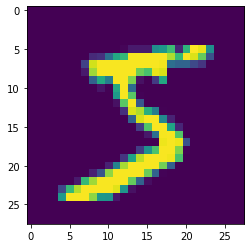

In [5]:
image = mnist_images[0][0]
target_label = 3
model = fc_model

plt.imshow(image[0])

Our approach is as follows:

- We will create a random noise $\epsilon$ that is the same size 
  as the image.
- We will use an optimizer to tune the values of $\epsilon$ to
  make the neural network misclassify $x + \epsilon$ to our target class

The second step might sound a little mysterious, but is actually
very similar to tuning the weights of a neural network!

First, let's create some noise values. In order for PyTorch to be
able to tune these values using an optimizer, we need to
set `requires_grad=True`:

In [6]:
noise = torch.randn(1, 28, 28) * 0.01
noise.requires_grad = True

Now, we will tune the noise:

In [7]:
optimizer = optim.Adam([noise], lr=0.01, weight_decay=1)
criterion = nn.CrossEntropyLoss()

for i in range(1000):
    adv_image = torch.clamp(image + noise, 0, 1)
    out = model(adv_image.unsqueeze(0))
    loss = criterion(out, torch.Tensor([target_label]).long())
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

To keep the pixel values in `noise` small,
we use a fairly large `weight_decay`. We use the `CrossEntropyLoss`,
but maximize the neural network prediction of our `target_label`.

Notice also that the `adv_image` is clamped so that the pixel values
are kept in the range [0, 1].

Now, let's see the resulting image:

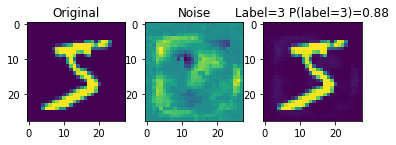

In [8]:
adv_image = torch.clamp(image + noise, 0, 1)
adv_label = torch.argmax(model(adv_image), dim=1).item()
adv_percent = torch.softmax(model(adv_image), dim=1)[0,target_label].item()

plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(image[0])

plt.subplot(1, 3, 2)
plt.title("Noise")
plt.imshow(noise[0].detach().numpy())

plt.subplot(1, 3, 3)
plt.title("Label=%d P(label=%d)=%.2f" % (adv_label, target_label, adv_percent))
plt.imshow(adv_image.detach().numpy()[0])

The image on the right still looks like a "5" to a human.
However, the neural network misclassifies the image.

The same steps can be used to create an adversarial attack
for other images, and for other model architectures.

In [9]:
def create_adversarial_example(model, image, target_label):
    noise = torch.randn(1, 28, 28)
    noise.requires_grad = True
    
    optimizer = optim.Adam([noise], lr=0.01, weight_decay=1)
    criterion = nn.CrossEntropyLoss()

    for i in range(1000):
        adv_image = torch.clamp(image + noise, 0, 1)
        out = model(adv_image.unsqueeze(0))
        loss = criterion(out, torch.Tensor([target_label]).long())
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

  
    adv_image = torch.clamp(image + noise, 0, 1)
    adv_label = torch.argmax(model(adv_image.unsqueeze(0)), dim=1).item()
    adv_percent = torch.softmax(model(adv_image.unsqueeze(0)), dim=1)[0,target_label].item()

    plt.subplot(1, 3, 1)
    plt.title("Original")
    plt.imshow(image[0])
    
    plt.subplot(1, 3, 2)
    plt.title("Noise")
    plt.imshow(noise[0].detach().numpy())
    
    plt.subplot(1, 3, 3)
    plt.title("Label=%d P(label=%d)=%.2f" % (adv_label, target_label, adv_percent))
    plt.imshow(adv_image.detach().numpy()[0])

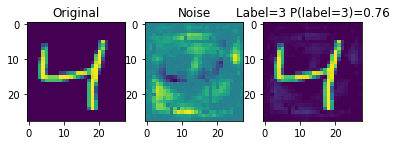

In [10]:
create_adversarial_example(fc_model, mnist_images[2][0], 3)

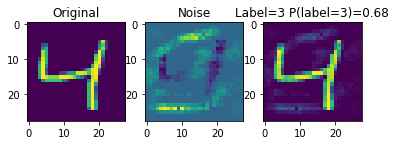

In [11]:
create_adversarial_example(cnn_model, mnist_images[2][0], 3)

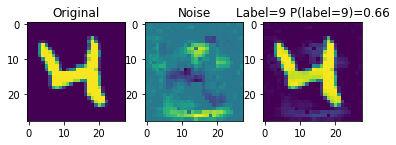

In [12]:
create_adversarial_example(fc_model, mnist_images[20][0], 9)

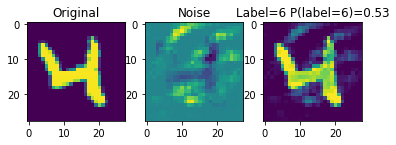

In [13]:
create_adversarial_example(cnn_model, mnist_images[20][0], 6)

# Results

## Summary

This notebook demonstrated gradient-based adversarial attacks against image classification models.

### Implemented Techniques

- Targeted adversarial attacks
- Gradient-based perturbation optimization
- Adversarial image generation
- Robustness evaluation

### Key Outcomes

- Successfully generated adversarial examples capable of changing model predictions.
- Visualized perturbations that remain nearly imperceptible to humans.
- Demonstrated how small input modifications can significantly affect neural network predictions.
- Explored optimization strategies for generating targeted adversarial examples.

These experiments highlight the importance of evaluating model robustness alongside predictive accuracy when developing deep learning systems.

# Conclusion

Adversarial attacks reveal important limitations of deep neural networks by demonstrating that carefully optimized perturbations can cause significant prediction errors while remaining visually indistinguishable from the original images. Understanding these vulnerabilities is essential for developing more robust, reliable, and secure AI systems. This notebook provides a practical introduction to adversarial machine learning and serves as a foundation for studying adversarial defenses and robust model training.